# Duration distribution plots

Notebook for binning and generating duration, distance, and speed plots for one selected dataset.


In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Could not find project root containing Data/")


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "Data"
PRESENTATION_DIR = PROJECT_ROOT / "notebooks" / "04_data_presentation"

if str(PRESENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(PRESENTATION_DIR))

import duration_plot_utils as dpu


## ---------- Dataset configuration ----------


In [11]:
DATASETS = dpu.dataset_paths(DATA_DIR)

# Options: "full_dataset", "without_discontinuities"
DATASET_NAME = "full_dataset"
DATASET_LABEL = "Pełny zbiór"
DATA_FILE = DATASETS[DATASET_NAME]

lower_limit = 0
upper_limit = 10**6
a_values = [1.5, 1.75, 2]
speed_a_values = [1.5, 1.75, 2]

print(DATA_FILE)


/Users/artur/Studia/Rowerki/Data/final_trip_data.parquet


## ---------- Loading and preparing data ----------


In [12]:
dur_dist_data = dpu.load_duration_data(DATA_FILE)
dur_dist_data_weekdays, dur_dist_data_weekends = dpu.split_weekdays_weekends(dur_dist_data)

display(dur_dist_data.head())


,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,start_lat,start_lon,start_station_id,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,duration_min_bin,duration_counts
4872313,2.0,CLASSIC,2024-08-01 08:26:00,51.500744,-0.202759,1115.0,"Ilchester Place, Kensington",11.269322,2024-08-01 08:12:00,Thursday,51.476885,-0.215896,200029,"Finlay Street, Fulham",2.804527,14m 55s,14.931833,141622479,14.0,NaN
4863098,2.0,CLASSIC,2024-08-01 13:43:00,51.494224,-0.236770,300037.0,"Ravenscourt Park Station, Hammersmith",8.507715,2024-08-01 13:26:00,Thursday,51.500744,-0.202759,1115,"Ilchester Place, Kensington",2.463470,17m 22s,17.373433,141631864,17.0,NaN
4809152,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,51.494224,-0.236770,300037,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,3.0,NaN
4757263,2.0,CLASSIC,2024-08-05 08:58:00,51.514767,-0.225787,200136.0,"BBC White City, White City",9.351433,2024-08-05 08:43:00,Monday,51.494499,-0.228188,200166,"Southerton Road, Hammersmith",2.259820,14m 29s,14.499300,141741326,14.0,NaN
3204525,2.0,CLASSIC,2024-09-05 12:00:00,51.514441,-0.087587,1201.0,"Bank of England Museum, Bank",11.196041,2024-09-05 11:51:00,Thursday,51.529537,-0.083353,3427,"Fanshaw Street, Hoxton",1.703944,9m 7s,9.131500,142640332,9.0,NaN


In [13]:
dpu.duration_quantiles(dur_dist_data)


0.0500         3.275350
0.5000        13.155117
0.9000        31.550567
0.9500        41.687857
0.9900        85.923130
0.9990       822.325688
0.9999     13409.744052
1.0000    272120.613633
Name: total_duration_minutes, dtype: float64

In [14]:
coverage = dpu.duration_range_coverage(
    dur_dist_data,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)


Liczba przejazdów w zakresie 0-1000000 min: 17426293
Liczba wszystkich przejazdów: 17426293
Udział danych w tym zakresie: 100.00%


In [15]:
# ---------- Min and max duration by day type ----------

dpu.print_min_max_duration_by_day_type(
    dur_dist_data_weekdays,
    dur_dist_data_weekends,
)


Weekdays
Min duration [min]: 0.003266666666666667
Max duration [min]: 270479.20423333335
---------------------------------
Weekends
Min duration [min]: 0.007033333333333333
Max duration [min]: 272120.61363333336


In [16]:
# ---------- Counting rides by duration ----------

duration_counts_weekdays, duration_counts_weekends = dpu.count_rides_by_duration(
    dur_dist_data_weekdays,
    dur_dist_data_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)


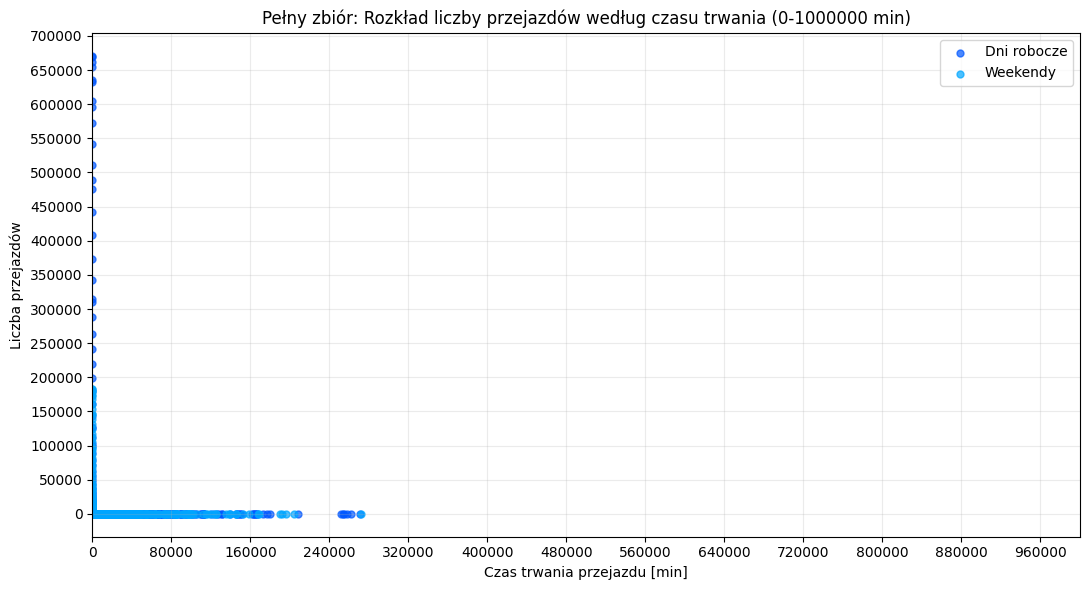

: 

In [ ]:
# ---------- Duration counts: weekdays vs weekends ----------

ax = dpu.plot_duration_counts(
    duration_counts_weekdays,
    duration_counts_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    title_prefix=DATASET_LABEL,
)
plt.tight_layout()
plt.show()


# 1.Histograms


In [ ]:
# ---------- Preparing duration data ----------

duration_weekdays, duration_weekends = dpu.prepare_duration_data(
    dur_dist_data_weekdays,
    dur_dist_data_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)

results = dpu.calculate_duration_log_binning_results(
    duration_weekdays,
    duration_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    a_values=a_values,
)


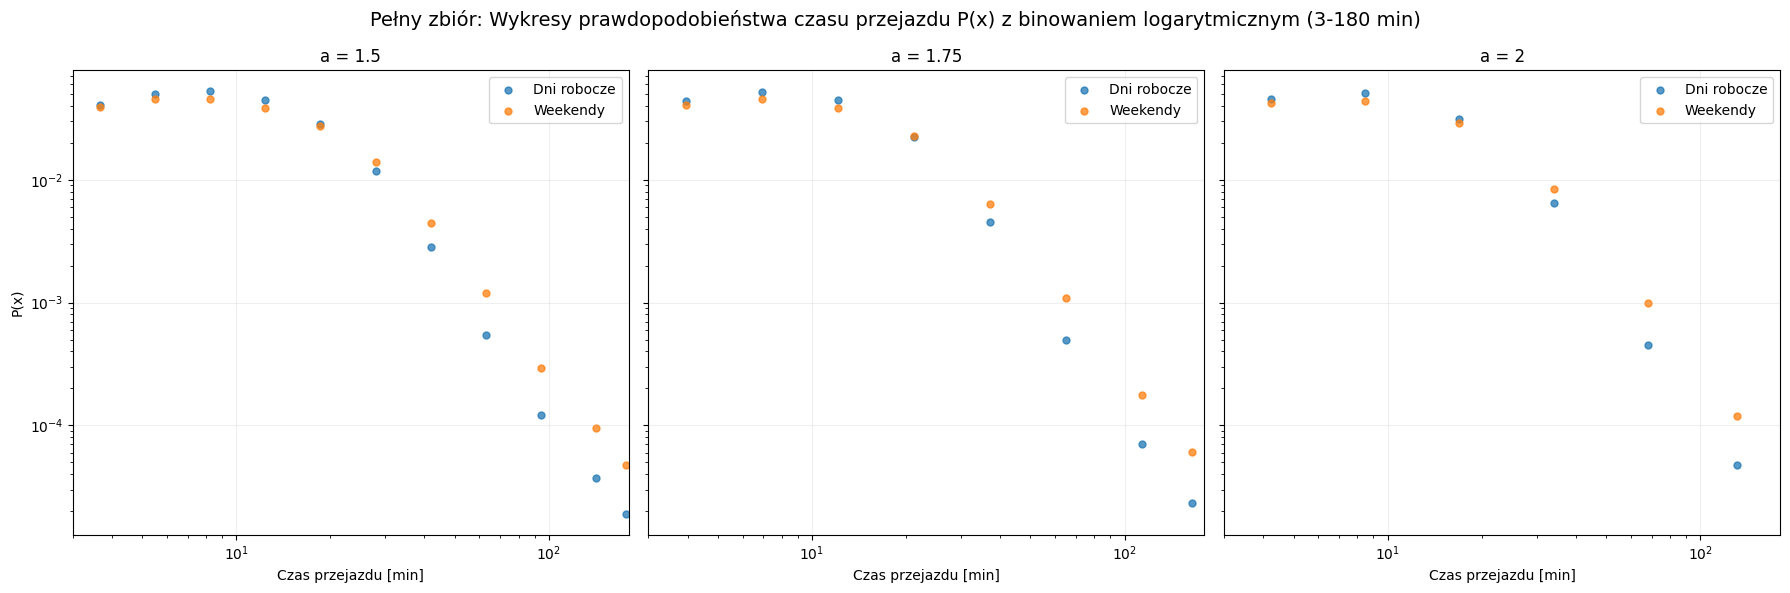

In [ ]:
# ---------- Plotting logarithmic probability density ----------

fig, axes = dpu.plot_duration_log_probability(
    results,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    a_values=a_values,
    title_prefix=DATASET_LABEL,
)
plt.show()


Zakres dopasowania:
x_min = 15
x_max = 1000

Dni robocze:
Nachylenie = -3.396
Wyraz wolny = 2.874

Weekendy:
Nachylenie = -2.936
Wyraz wolny = 2.307


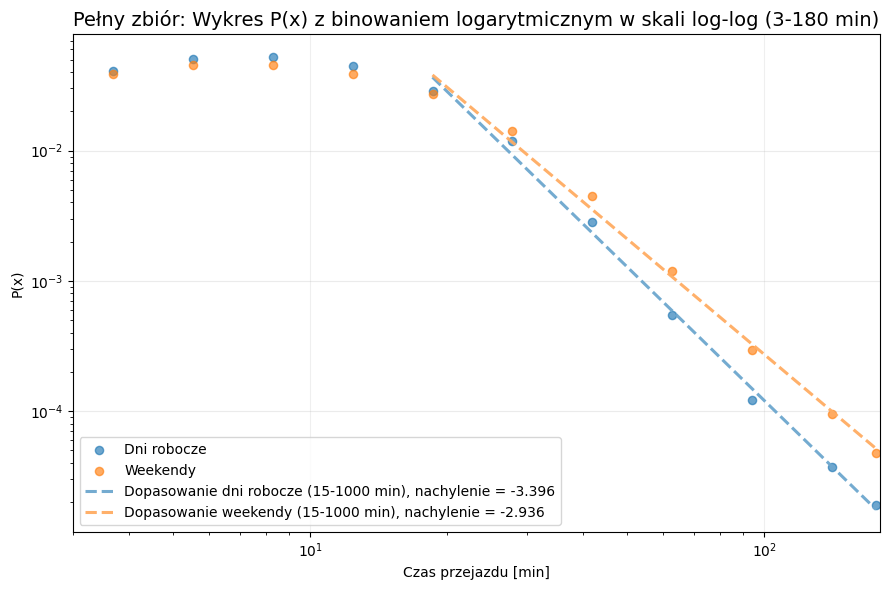

In [ ]:
# ---------- Separate tail fits for weekdays and weekends ----------

tail_fit = dpu.plot_duration_tail_fit(
    results,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    a_value=1.5,
    x_min=15,
    x_max=1000,
    title_prefix=DATASET_LABEL,
)
plt.tight_layout()
plt.show()


# Histogram prędkości


# Odległość przejazdów w linii prostej


In [ ]:
# ---------- Straight-line distance between start and end stations ----------

# This column is prepared in data_preparation.ipynb.
ride_distance_data = dpu.prepared_ride_distance_data(dur_dist_data)

display(
    ride_distance_data["straight_line_distance_km"].describe(
        percentiles=[0.05, 0.5, 0.9, 0.95, 0.99]
    )
)

display(
    ride_distance_data
    .sort_values("straight_line_distance_km", ascending=False)
    .head()
)


Liczba przejazdów: 17426293
Liczba przejazdów z brakującymi współrzędnymi: 0


count    1.742629e+07
mean     2.378230e+00
std      1.736340e+00
min      0.000000e+00
5%       3.420790e-01
50%      1.985467e+00
90%      4.702962e+00
95%      5.774866e+00
99%      8.081387e+00
max      1.696891e+01
Name: straight_line_distance_km, dtype: float64

,trip_id,start_date,end_date,total_duration_minutes,start_lat,start_lon,end_lat,end_lon,straight_line_distance_km
3583672,137489653,2024-02-24 12:20:00,2024-02-24 14:06:00,105.153683,51.546326,-0.009935,51.463211,-0.215551,16.968915
3583685,137489640,2024-02-24 12:20:00,2024-02-24 14:06:00,105.405000,51.546326,-0.009935,51.463211,-0.215551,16.968915
702195,140275736,2024-06-17 18:35:00,2024-06-17 19:40:00,65.797917,51.464786,-0.215619,51.541793,-0.004810,16.918216
8520382,140049573,2024-06-09 13:37:00,2024-06-09 14:44:00,67.649733,51.494224,-0.236770,51.541793,-0.004810,16.899189
14062480,151049463,2025-08-07 17:21:00,2025-08-07 18:50:00,88.415300,51.494224,-0.236770,51.541793,-0.004810,16.899189


In [ ]:
dur_dist_data.head()


,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,start_lat,start_lon,start_station_id,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,duration_min_bin,duration_counts
4872313,2.0,CLASSIC,2024-08-01 08:26:00,51.500744,-0.202759,1115.0,"Ilchester Place, Kensington",11.269322,2024-08-01 08:12:00,Thursday,51.476885,-0.215896,200029,"Finlay Street, Fulham",2.804527,14m 55s,14.931833,141622479,14.0,NaN
4863098,2.0,CLASSIC,2024-08-01 13:43:00,51.494224,-0.236770,300037.0,"Ravenscourt Park Station, Hammersmith",8.507715,2024-08-01 13:26:00,Thursday,51.500744,-0.202759,1115,"Ilchester Place, Kensington",2.463470,17m 22s,17.373433,141631864,17.0,NaN
4809152,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,51.494224,-0.236770,300037,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,3.0,NaN
4757263,2.0,CLASSIC,2024-08-05 08:58:00,51.514767,-0.225787,200136.0,"BBC White City, White City",9.351433,2024-08-05 08:43:00,Monday,51.494499,-0.228188,200166,"Southerton Road, Hammersmith",2.259820,14m 29s,14.499300,141741326,14.0,NaN
3204525,2.0,CLASSIC,2024-09-05 12:00:00,51.514441,-0.087587,1201.0,"Bank of England Museum, Bank",11.196041,2024-09-05 11:51:00,Thursday,51.529537,-0.083353,3427,"Fanshaw Street, Hoxton",1.703944,9m 7s,9.131500,142640332,9.0,NaN


Liczba przejazdów w zakresie 3-180 min z policzoną prędkością: 16223608


count    1.622361e+07
mean     1.016254e+01
std      3.474222e+00
min      5.276942e-03
5%       3.516790e+00
50%      1.043609e+01
90%      1.429830e+01
95%      1.544872e+01
99%      1.764859e+01
99.5%    1.845735e+01
max      6.840017e+01
Name: speed_km_per_h, dtype: float64

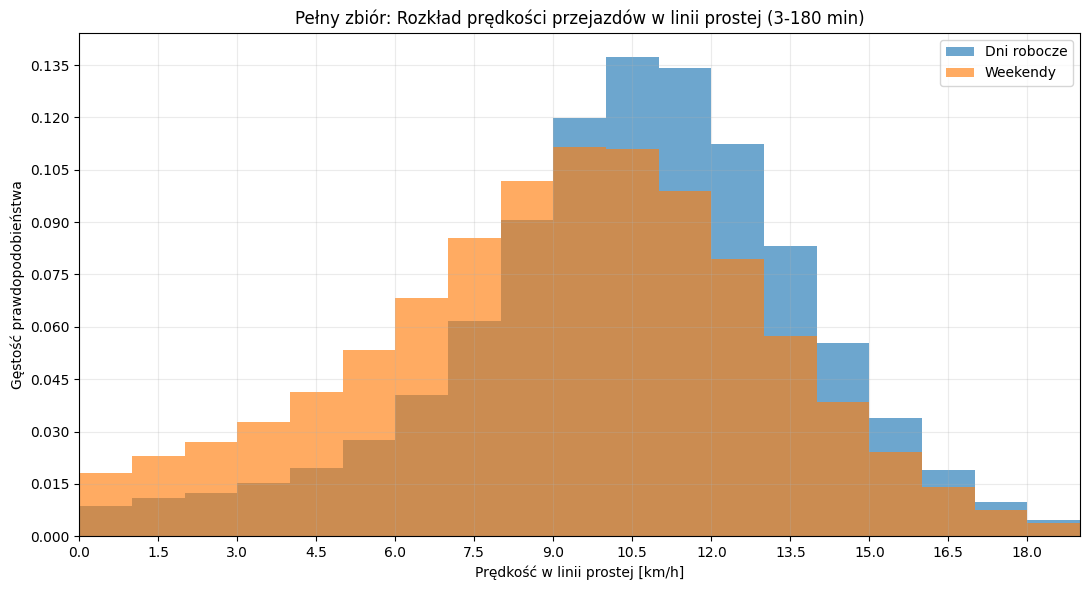

In [ ]:
# ---------- Speed distribution for rides within the selected duration range ----------

speed_distribution_data, speed_weekdays, speed_weekends = dpu.prepare_speed_distribution_data(
    dur_dist_data,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)

display(
    speed_distribution_data["speed_km_per_h"].describe(
        percentiles=[0.05, 0.5, 0.9, 0.95, 0.99, 0.995]
    )
)

ax = dpu.plot_speed_histogram(
    speed_distribution_data,
    speed_weekdays,
    speed_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    title_prefix=DATASET_LABEL,
)
plt.tight_layout()
plt.show()



a = 1.5
Number of bins: 24
First bin edges: [0.00527694 0.00791541 0.01187312 0.01780968 0.02671452]
Last bin edges: [17.54718795 26.32078193 39.4811729  59.22175935 68.40017186]

a = 1.75
Number of bins: 17
First bin edges: [0.00527694 0.00923465 0.01616064 0.02828111 0.04949195]
Last bin edges: [ 7.61863171 13.33260549 23.3320596  40.83110431 68.40017186]

a = 2
Number of bins: 14
First bin edges: [0.00527694 0.01055388 0.02110777 0.04221554 0.08443108]
Last bin edges: [ 5.40358893 10.80717787 21.61435573 43.22871146 68.40017186]


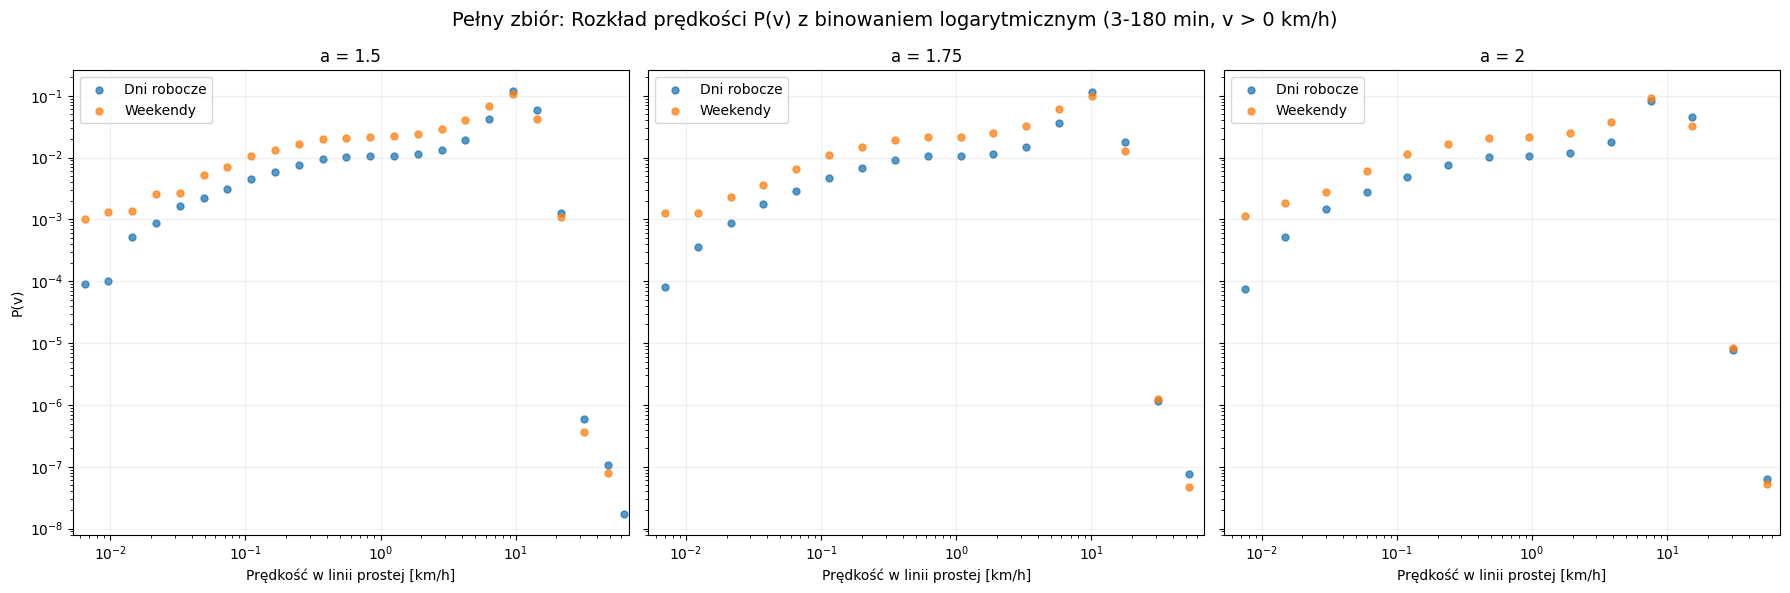

In [ ]:
# ---------- Logarithmic speed distribution ----------

speed_results, min_speed, max_speed = dpu.calculate_speed_log_binning_results(
    speed_distribution_data,
    speed_weekdays,
    speed_weekends,
    speed_a_values=speed_a_values,
)

fig, axes = dpu.plot_speed_log_probability(
    speed_results,
    min_speed,
    max_speed,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    speed_a_values=speed_a_values,
    title_prefix=DATASET_LABEL,
)
plt.show()
